In [1]:
import time
import torch
import torchvision
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

#### 4.2.1 Loading the Dataset

In [2]:
class FashionMNIST(d2l.DataModule):  #@save
    """The Fashion-MNIST dataset."""
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()
        trans = transforms.Compose([transforms.Resize(resize), 
                                    transforms.ToTensor()])
        self.train = torchvision.datasets.FashionMNIST(
            root=self.root, train=True, transform=trans, download=True)
        self.val = torchvision.datasets.FashionMNIST(
            root=self.root, train=False, transform=trans, download=True)

In [3]:
data = FashionMNIST(resize=(32, 32))
len(data.train), len(data.val)

(60000, 10000)

In [4]:
data.train[0][0].shape

torch.Size([1, 32, 32])

#### 4.2.2 Reading a Minibatch

In [5]:
@d2l.add_to_class(FashionMNIST)  #@save
def text_labels(self, indices):
    """Return text labels."""
    labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat', 
              'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [labels[int(i)] for i in indices]

In [6]:
@d2l.add_to_class(FashionMNIST)  #@save
def get_dataloader(self, train):
    data = self.train if train else self.val
    return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train, 
                                        num_workers=self.num_workers)

In [7]:
X, y = next(iter(data.train_dataloader()))
print(X.shape, X.dtype, y.shape, y.dtype)

torch.Size([64, 1, 32, 32]) torch.float32 torch.Size([64]) torch.int64


batch size, number of channels, height, width

In [8]:
tic = time.time()
for X, y in data.train_dataloader():
    continue
f'{time.time() - tic:.2f}sec'

'3.93sec'

#### 4.2.3 Visualization

In [9]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):  #@save
    """Plot a list of images."""
    raise NotImplementedError

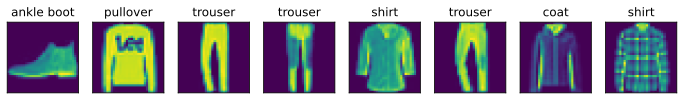

In [10]:
@d2l.add_to_class(FashionMNIST)   #@save
def visualize(self, batch, nrows=1, ncols=8, labels=[]):
    X, y = batch
    if not labels:
        labels = self.text_labels(y)
    d2l.show_images(X.squeeze(1), nrows, ncols, titles=labels)
batch = next(iter(data.val_dataloader()))
data.visualize(batch)

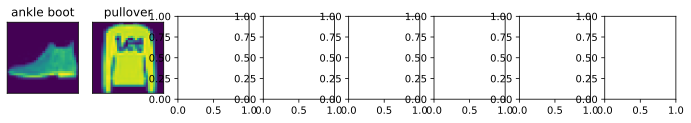

In [13]:
# exercise_1
data_exe1 = FashionMNIST(batch_size=2, resize=(32, 32))
# len(data_exe1.train), len(data_exe1.val), data_exe1.train[0][0].shape

batch_exe1 = next(iter(data_exe1.val_dataloader()))
data_exe1.visualize(batch_exe1)


#### exercise_2
1. 评估当前操作的速度：
数据的大小、数据的预处理复杂度、硬件性能（如 CPU、GPU 的性能）、数据加载器的配置等。如果数据量较小，预处理简单，并且硬件性能良好，那么这个操作可能相对较快；但如果数据量很大，预处理复杂，或者硬件性能有限，那么这个操作可能会花费较长时间，速度就不够快。
2. 探索提升性能的方法：
增加批大小（batch size）：适当增大数据加载器中设置的批大小。更大的批大小可以在一次迭代中加载更多的数据，减少迭代次数，从而可能提高整体的数据加载速度。例如，如果原来的批大小设置为 32，可以尝试增加到 64 或 128，但要注意不要设置得过大，否则可能会导致内存不足等问题。
3. 优化数据预处理：检查数据预处理的代码，看是否有可以优化的地方。例如，是否可以使用更高效的算法进行数据转换、归一化等操作；是否可以将一些预处理步骤提前进行，而不是在每次加载数据时都进行。
启用数据加载的异步操作：许多数据加载器支持异步加载数据，这样可以在 CPU 进行其他操作时，同时在后台加载数据，提高效率。例如，在 PyTorch 中，可以在创建数据加载器时设置 num_workers 参数为一个大于 0 的值（表示使用多个子进程进行数据加载），并根据硬件情况合理设置这个值。
4. 使用缓存：对于一些经常使用的数据，可以考虑使用缓存机制，避免重复加载和预处理。例如，可以将预处理后的数据保存到磁盘或内存缓存中，下次使用时直接读取缓存中的数据。
5. 使用系统性能分析器找出瓶颈：
PyTorch Profiler：如果是在 PyTorch 环境中，可以使用 torch.profiler 来分析代码的性能。它可以记录代码中各个操作的时间开销，帮助找出哪些操作花费的时间最长，从而确定性能瓶颈。例如：
```python
import torch
import torch.profiler

with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CPU,
        torch.profiler.ProfilerActivity.CUDA
    ],
    schedule=torch.profiler.schedule(wait=1, warmup=1, active=3),
    on_trace_ready=torch.profiler.tensorboard_trace_handler('./log')
) as prof:
    for _ in range(5):
        batch = next(iter(data.val_dataloader()))
        # 假设这里有对数据的其他操作
        # 比如在 GPU 上进行计算等
        if torch.cuda.is_available():
            batch = [tensor.cuda() for tensor in batch]
        prof.step()
```

其他性能分析工具：根据使用的编程语言和框架，还可以使用其他性能分析工具，如 Python 的 cProfile（用于分析 Python 代码的性能）、NVIDIA 的 Nsight Systems（用于分析 GPU 相关的性能）等。



#### exercise_3
How...could I check without the web location...